In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/test_batch
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-batches-py/readme.html
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/asadkhan0313/dataset-cifer/data/cifar-10-python/cifar-10-batches-py/

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.transforms import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader,WeightedRandomSampler,random_split

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [6]:
trian_data = CIFAR10(
    root='/kaggle/input/datasets/asadkhan0313/dataset-cifer/data',
    train=True,
    transform=transform,
    download=True
)


In [7]:
test_data = CIFAR10(
    root='/kaggle/input/datasets/asadkhan0313/dataset-cifer/data',
    train=False,
    transform=transform,
    download=True
)


In [8]:
from collections import Counter

train_counts = Counter(trian_data.targets)
test_counts = Counter(test_data.targets)

print("Train:", dict(sorted(train_counts.items())))
print("Test:", dict(sorted(test_counts.items())))

Train: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}
Test: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


In [9]:
trian_loader = DataLoader(
    trian_data,
    shuffle=True,
    batch_size=128
)

test_loader = DataLoader(
    test_data,
    shuffle=False,
    batch_size=128
)

In [10]:
from torchvision import models
import torch.nn as nn

resnet_model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features,10)
resnet_model = resnet_model.to(device)
optimizer = optim.Adam(resnet_model.parameters(),lr=0.001)
loss_fn = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 


In [12]:
epochs = 5

for epoch in range(epochs):

    resnet_model.train()
    total_loss = 0

    for images, labels in trian_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        output = resnet_model(images)

        # Calculate loss
        loss = loss_fn(output, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    # Average loss for this epoch
    avg_loss = total_loss / len(trian_loader)

    print(
        f"Epoch: {epoch+1}/{epochs} | "
        f"Total Loss: {total_loss:.4f} | "
        f"Avg Loss: {avg_loss:.4f}"
    )

Epoch: 1/5 | Total Loss: 109.3211 | Avg Loss: 0.2796
Epoch: 2/5 | Total Loss: 72.7714 | Avg Loss: 0.1861
Epoch: 3/5 | Total Loss: 52.7979 | Avg Loss: 0.1350
Epoch: 4/5 | Total Loss: 35.9335 | Avg Loss: 0.0919
Epoch: 5/5 | Total Loss: 29.6792 | Avg Loss: 0.0759


In [16]:
resnet_model.eval()
correct = 0 
total =0
for images,labels in test_loader:
        images,labels = images.to(device),labels.to(device)
        output = resnet_model(images)
        predict = output.argmax(dim=1)     
        correct += (predict == labels).sum().item()
        total += labels.size(0)
accuracy = 100*correct/total
print(f"Test Acc: {accuracy:.2f}%")

Test Acc: 91.08%


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

all_pred = []
all_labels = []

resnet_model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        images,labels = images.to(device),labels.to(device)
        output = resnet_model(images)
        prediction = output.argmax(dim=1)
        all_pred.extend(prediction.tolist())
        all_labels.extend(labels.tolist())

print(confusion_matrix(all_labels, all_pred))
print(classification_report(all_labels, all_pred, target_names=test_data.classes))

[[905   3  35  10   2   2   2   2  29  10]
 [  2 971   2   1   1   0   0   0   1  22]
 [ 13   0 885  38  19  24  16   4   1   0]
 [  3   0  17 888  13  59  11   2   4   3]
 [  2   1  14  42 906  11   4  19   1   0]
 [  2   1   7 115  11 853   5   5   0   1]
 [  3   1  18  46   9   8 914   1   0   0]
 [  6   2   9  31  13  23   0 916   0   0]
 [ 28   8   6   6   1   0   2   0 943   6]
 [ 10  31   4  10   0   0   0   2  16 927]]
              precision    recall  f1-score   support

    airplane       0.93      0.91      0.92      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.89      0.89      0.89      1000
         cat       0.75      0.89      0.81      1000
        deer       0.93      0.91      0.92      1000
         dog       0.87      0.85      0.86      1000
        frog       0.96      0.91      0.94      1000
       horse       0.96      0.92      0.94      1000
        ship       0.95      0.94      0.95      1000
       truck       0.96     

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
all_prob = []
all_labels = []

resnet_model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        images,labels = images.to(device),labels.to(device)
        output = resnet_model(images)
        probability = output.softmax(dim=1)
        all_prob.extend(probability.tolist())
        all_labels.extend(labels.tolist())

auc = roc_auc_score(
    all_labels,
    all_prob,
    multi_class='ovr',
    average='macro'
)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9956


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.5877128].


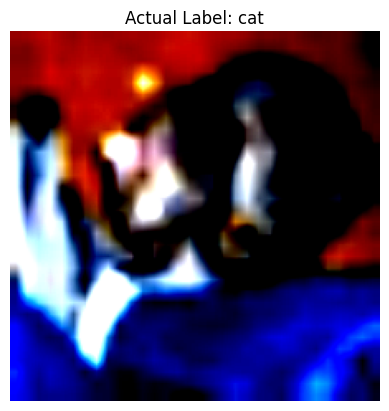

User Picked Index No: 0
Actual Label: 3 → cat
Predicted Label: 3 → cat


In [32]:
import matplotlib.pyplot as plt

index = 0

# Get image and actual label
image, label = test_data[index]

# Get class names
class_names = test_data.classes

# Display image
plt.imshow(image.permute(1, 2, 0))
plt.title(f'Actual Label: {class_names[label]}')
plt.axis('off')
plt.show()

# Add batch dimension
# [3, 32, 32] → [1, 3, 32, 32]
image = image.unsqueeze(0).to(device)

# Prediction
resnet_model.eval()

with torch.no_grad():

    output = resnet_model(image)

    predicted_label = output.argmax(dim=1).item()

# Convert numeric labels → class names
actual_class = class_names[label]
predicted_class = class_names[predicted_label]

print(f'User Picked Index No: {index}')
print(f'Actual Label: {label} → {actual_class}')
print(f'Predicted Label: {predicted_label} → {predicted_class}')

In [33]:
torch.save(resnet_model.state_dict(),'Multi_class_Ditection.pth')
print('Model is save')

Model is save
